# Machine learning approach 

During this notebook, we are testing different ML algorithms to tackle hypoglycemia prediction problem  

Create our own class to compare different models against several horizons and metrics

In [1]:
import os 
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [ ]:
class Models_Horizon():
    def __init__(self, cut_point:int, test_size:float , window_size:int, horizon:int, folds:int, models:list, model_names:list, metrics:list):
        self.cut_point = cut_point
        self.test_size = test_size
        self.window_size = window_size
        self.horizon = horizon
        self.folds = folds
        self.models = models
        self.model_names = model_names
        self.metrics = metrics


        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            data = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(data):
                k_train = data[k_fold[0]]
                k_test = data[k_fold[1]]
                proper_ml_train_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_train, window_size=self.window_size, horizon=self.horizon)
                proper_ml_test_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_test, window_size=self.window_size, horizon=self.horizon)
                patients[key].append((proper_ml_train_k_fold.generated_data_set, proper_ml_test_k_fold.generated_data_set))
        return patients
    
    def test_models(self):
        keys = list(self.patients.keys())
        results = []
        for key in keys:
            data_folds = self.patients[key] ## A list of tuples 
            columns = data_folds[0][0].columns ## Just to extract columns
            tensor_results_metrics = np.zeros(shape=(len(self.model_names), len(self.metrics), self.folds)) ## 3 cause, we're measuring MSE,MAE and MAPE

            for k, fold in enumerate(data_folds):
                train_k, test_k = fold[0], fold[1]
                X_train_k, y_train_k = train_k[columns[:-1]], train_k[columns[-1]]
                X_test_k, y_test_k = test_k[columns[:-1]], test_k[columns[-1]]
                for m, model in enumerate(self.models):
                    model = clone(model)
                    model.fit(X_train_k, y_train_k)
                    y_pred_k = model.predict(X_test_k)
                    for z, metric in enumerate(self.metrics):
                        result_metric = metric(y_true=y_test_k, y_pred=y_pred_k)
                        tensor_results_metrics[m][z][k] = result_metric
                        
            mse_all_models = tensor_results_metrics[:, 0, :]
            mae_all_models = tensor_results_metrics[:, 1, :]
            mape_all_models = tensor_results_metrics[:, 2, :]

            results.append(list(np.mean(mse_all_models, axis=1)) + list(np.mean(mae_all_models, axis=1)) + list(np.mean(mape_all_models, axis=1)))

        ### Prepare and return a df 
        metrics = ['mse', 'mae', 'mape']
        col_index = pd.MultiIndex.from_product([metrics, self.model_names], names=['metric', 'model'])
        df_final = pd.DataFrame(
            results,
            index=keys,
            columns=col_index
        )
        self.results = df_final
        return df_final

    def visualize_model_comparison(self, figsize=(15, 7)):
        if self.results is None:
            raise ValueError("No results to visualize. Run 'test_models()' first.")
    

        metrics = ['mse', 'mae', 'mape']
        model_names = self.model_names

        _, axes = plt.subplots(1, 3, figsize=figsize)
        colors = ['steelblue', 'seagreen', 'tomato']

        for ax, metric, color in zip(axes, metrics, colors):

            data_plot = self.results[metric]  

            data_long = data_plot.reset_index().melt(
                id_vars='index',
                var_name='Model',
                value_name=metric.upper()
            )
            data_long['Model'] = pd.Categorical(data_long['Model'], categories=model_names)

    
            sns.boxplot(
                data=data_long,
                x='Model',
                y=metric.upper(),
                ax=ax,
                color=color,
                width=0.6
            )

            ax.set_title(f'{metric.upper()}: Window_size:{self.window_size}, Horizon:{self.horizon}')
            ax.set_xlabel('Modelo')
            ax.set_ylabel(metric.upper())
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        ## Visualize a summary for each metric
        for m in metrics:
            print(f'{m.upper()}')
            print(self.results[m].describe())
        

## Test it using random forest regressor and gradient boost regressor 

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

In [5]:
cut_point = 2290
test_size = 0.2
window_size = 20
horizon = 6
folds = 5
models = [
    RandomForestRegressor(
        n_estimators=100,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          # ← más bajo
        min_child_weight=10,  # ← clave para evitar hojas pequeñas
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ),
    LinearRegression()
]
model_names = ['random_forest', 'gradient_boost', 'xgboost', 'linear_regression']
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]

In [6]:
horizon_3 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=horizon, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

In [7]:
results = horizon_3.test_models()

In [8]:
results.shape

(25, 12)

In [13]:
results

metric              mse                                                \
model     random_forest gradient_boost      xgboost linear_regression   
HUPA0004P    772.317804     561.050303   603.325728        295.339691   
HUPA0006P    826.581822     750.409984   749.139388        286.517263   
HUPA0007P   1285.351459    1176.620338  1221.689396       1037.724498   
HUPA0009P    249.799669     339.687608   311.779713         66.055376   
HUPA0005P    396.108029     403.174713   381.912552        311.941810   
HUPA0011P   1026.329386     989.461093  1030.142901        555.292817   
HUPA0003P    577.057979     619.698695   595.483975        438.447085   
HUPA0001P   1306.289392    1278.571428  1271.151889        942.120577   
HUPA0010P    626.564136     425.055068   496.114338        212.071313   
HUPA0002P    436.522271     444.238950   470.485251        189.651693   
HUPA0014P   1149.840099    1002.738329  1021.949127        282.393100   
HUPA0015P    645.641742     515.580415   551.415956        278.238961   
HUPA0016P    526.992450     511.379614   534.146411        292.099028   
HUPA0017P    481.987411     433.511627   439.475820        281.936845   
HUPA0018P    687.426668     616.219853   668.746449        300.232100   
HUPA0021P    724.080563     613.279191   638.307064        375.337296   
HUPA0020P    581.365162     486.730277   514.606302        263.707555   
HUPA0024P    545.286323     418.225278   417.502826        229.148033   
HUPA0019P    980.363121     911.961953   935.474429        485.908814   
HUPA0023P    487.493896     515.608238   549.497931        249.978417   
HUPA0022P    302.031474     335.931926   333.208147        260.811748   
HUPA0025P    286.891678     249.813110   263.213466        153.657999   
HUPA0028P    545.660306     491.828489   493.102704        314.455936   
HUPA0026P    575.909655     506.718130   542.676289        306.395205   
HUPA0027P    297.396689     328.168303   335.130512        201.878299   

metric              mae                                              \
model     random_forest gradient_boost    xgboost linear_regression   
HUPA0004P     21.246970      18.122386  18.722910         12.390793   
HUPA0006P     21.623276      20.573757  20.598184         12.202907   
HUPA0007P     27.613259      25.525355  25.895326         23.928428   
HUPA0009P     11.443426       9.869861   9.944062          3.659663   
HUPA0005P     14.806363      15.049636  14.727222         13.052902   
HUPA0011P     22.652238      21.865098  22.092816         16.767970   
HUPA0003P     18.689458      18.597447  18.411444         14.567085   
HUPA0001P     26.337127      24.802622  24.945884         21.371832   
HUPA0010P     16.708216      12.973203  14.246118          9.989219   
HUPA0002P     15.324144      15.469235  16.020187         10.061191   
HUPA0014P     20.545623      18.944728  19.057830         11.372188   
HUPA0015P     18.722629      16.830891  17.548847         11.800541   
HUPA0016P     16.796949      17.044453  17.523229         12.138345   
HUPA0017P     16.772517      15.114121  15.273332         12.094022   
HUPA0018P     20.302289      17.884826  18.607567         12.484640   
HUPA0021P     19.828166      17.813881  18.269689         13.503677   
HUPA0020P     18.946363      16.855937  17.527427         12.012129   
HUPA0024P     17.440659      15.741289  15.616644         10.893359   
HUPA0019P     22.610673      21.750928  22.071767         15.688734   
HUPA0023P     15.962522      16.202769  16.570112         11.331229   
HUPA0022P     13.284906      13.999527  13.868397         11.618041   
HUPA0025P     13.091691      12.543730  12.769994          9.345282   
HUPA0028P     17.247152      15.720486  15.978271         12.742164   
HUPA0026P     17.698359      16.315037  16.975860         11.686381   
HUPA0027P     13.190816      13.145870  13.470250         10.272624   

metric             mape                                             
model     random_forest gradient_boost   

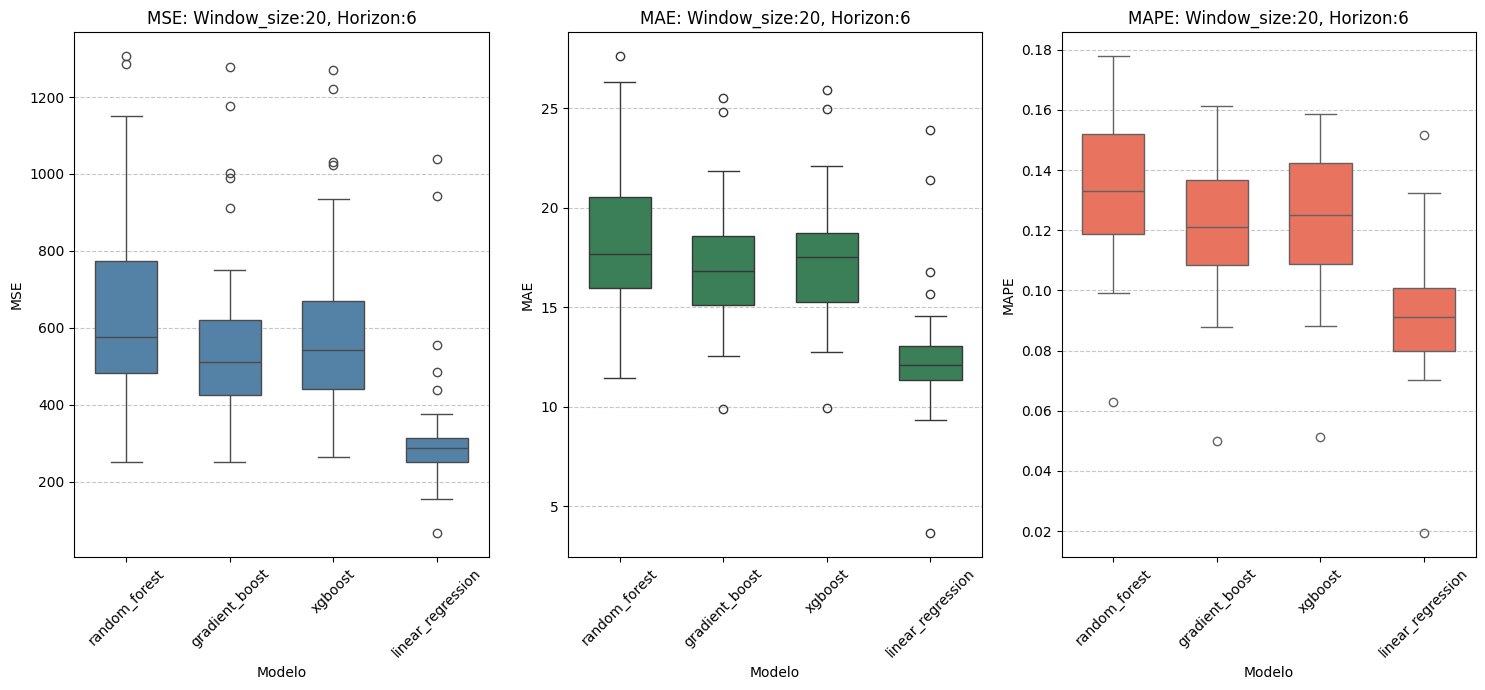

MSE
model  random_forest  gradient_boost      xgboost  linear_regression
count      25.000000       25.000000    25.000000          25.000000
mean      652.851567      597.026517   614.787142         344.453658
std       298.815726      271.770102   276.799782         218.856720
min       249.799669      249.813110   263.213466          66.055376
25%       481.987411      425.055068   439.475820         249.978417
50%       577.057979      511.379614   542.676289         286.517263
75%       772.317804      619.698695   668.746449         314.455936
max      1306.289392     1278.571428  1271.151889        1037.724498
MAE
model  random_forest  gradient_boost    xgboost  linear_regression
count      25.000000       25.000000  25.000000          25.000000
mean       18.355432       17.150283  17.469335          12.679014
std         3.989035        3.684991   3.682093           3.849484
min        11.443426        9.869861   9.944062           3.659663
25%        15.962522       15.114121

In [14]:
horizon_3.visualize_model_comparison()